In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,6)

print("libraries imported successfully")

libraries imported successfully


In [2]:

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:

print("Shape of dataset:", df.shape)

df.info()

Shape of dataset: (9994, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   flo

In [4]:
# Missing values
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [5]:
# Statistical summary
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
# Remove duplicates
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (9994, 21)


In [8]:
# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Create Year and Month columns
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October


C:\Users\DEVANAND\AppData\Local\Temp\ipykernel_25364\968272402.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.values,


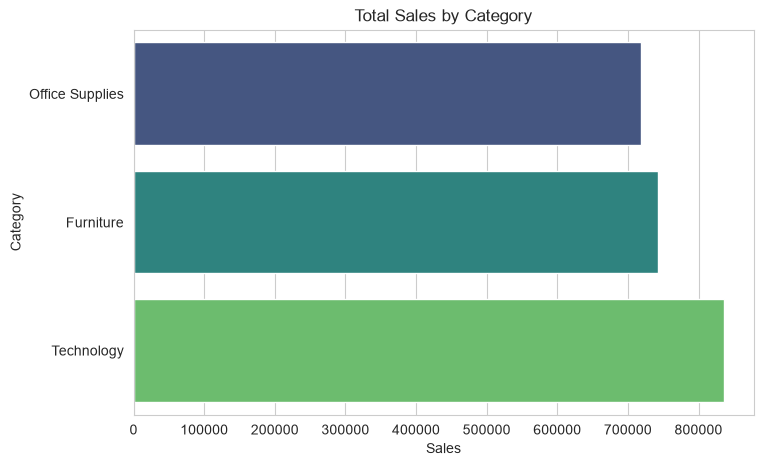

In [9]:
# Sales by Category
category_sales = df.groupby("Category")["Sales"].sum().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.values,
            y=category_sales.index,
            palette="viridis")

plt.title("Total Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.show()

Observation: Technology generates the highest sales, followed by Furniture and Office Supplies. This indicates that technology products contribute the most to the company's revenue.

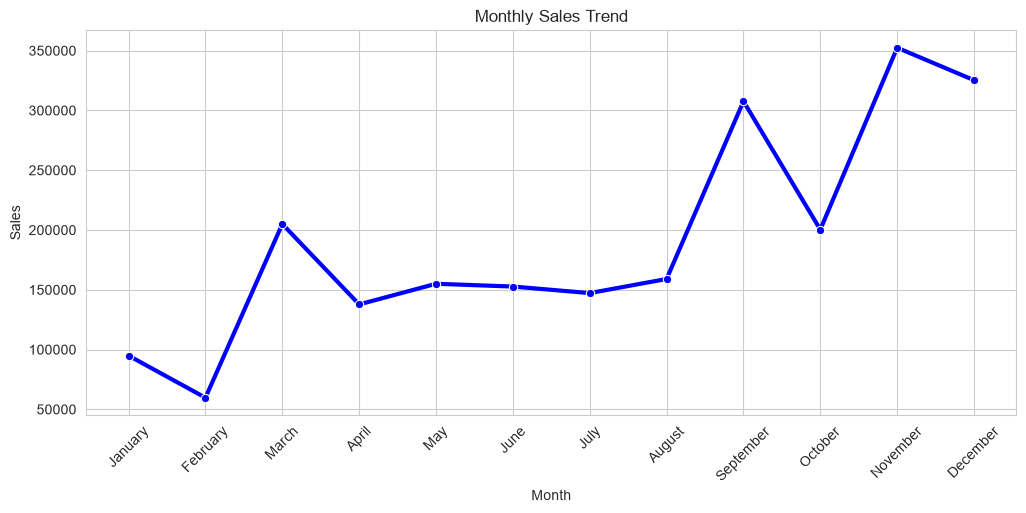

In [10]:
# Monthly Sales Trend
monthly_sales = df.groupby("Month")["Sales"].sum()

months = ["January","February","March","April","May","June",
          "July","August","September","October","November","December"]

monthly_sales = monthly_sales.reindex(months)

plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_sales.index,
             y=monthly_sales.values,
             marker="o",
             linewidth=3,
             color="blue")

plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Observation: Sales fluctuate throughout the year, with noticeable peaks during certain months, indicating seasonal demand.

C:\Users\DEVANAND\AppData\Local\Temp\ipykernel_25364\71663392.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values,


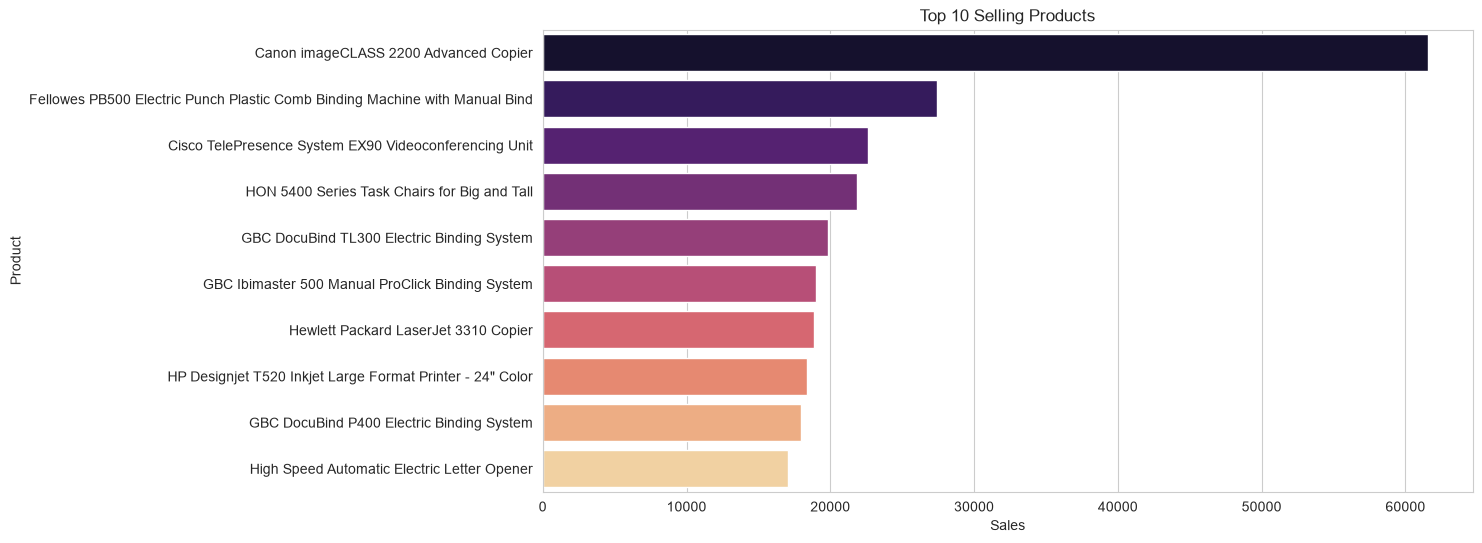

In [11]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values,
            y=top_products.index,
            palette="magma")

plt.title("Top 10 Selling Products")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

Observation: A small number of products contribute significantly to total sales, making them key revenue drivers.

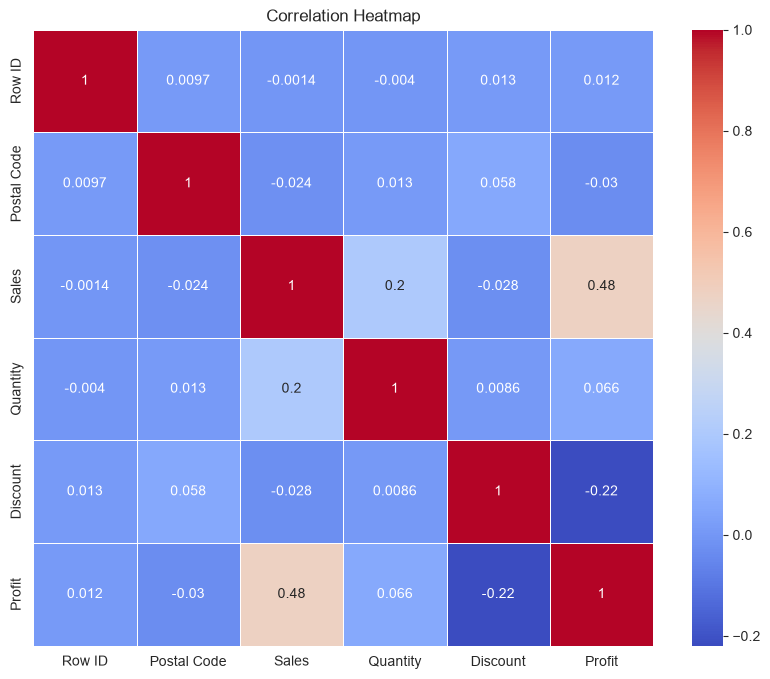

In [12]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Observation: Sales and Profit show a positive correlation, while Discount has a negative correlation with Profit. Increasing discounts may reduce profitability.

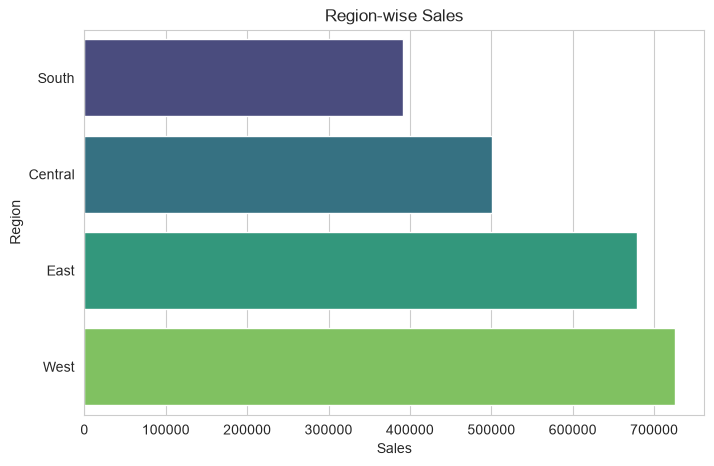

In [13]:
# Region-wise Sales

region_sales = df.groupby("Region")["Sales"].sum().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    hue=region_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Region-wise Sales")
plt.xlabel("Sales")
plt.ylabel("Region")
plt.show()

Observation: The West region generates the highest sales, whereas the South region contributes the least.

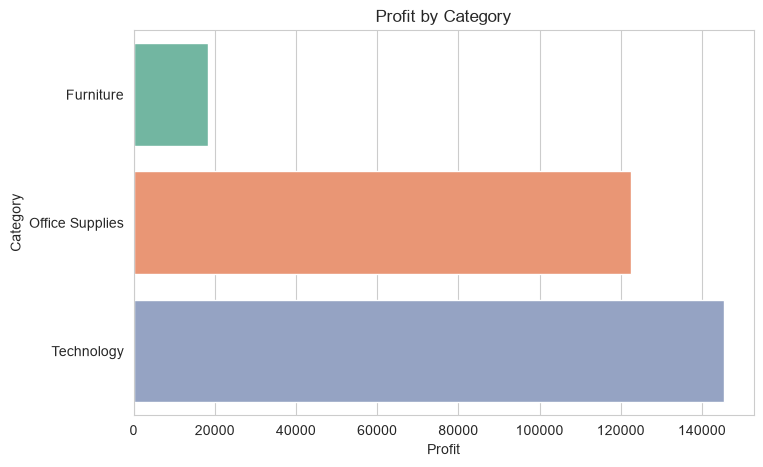

In [14]:
# Profit by Category

profit_category = df.groupby("Category")["Profit"].sum().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(
    x=profit_category.values,
    y=profit_category.index,
    hue=profit_category.index,
    palette="Set2",
    legend=False
)

plt.title("Profit by Category")
plt.xlabel("Profit")
plt.ylabel("Category")
plt.show()

Observation: Technology is the most profitable category, while Furniture earns comparatively lower profits despite high sales

# Business Recommendations

1. Increase investment in Technology products since they generate the highest revenue and profit.

2. Review discount policies because higher discounts reduce overall profitability.

3. Focus marketing campaigns on high-performing products and regions while improving sales strategies in low-performing regions.

# Conclusion

The Retail Sales dataset was analyzed using Python, Pandas, Matplotlib, and Seaborn.

Key findings include:
- Technology is the highest-selling and most profitable category.
- The West region contributes the highest sales.
- A few products generate a significant share of revenue.
- Discounts negatively impact profits.

This analysis can help businesses optimize inventory, pricing, and marketing strategies.